# Prelab 09: Exponentials and Uncertainty in Count Rates

In [1]:
%reset -f
import data_entry2
import numpy as np
import matplotlib.pyplot as plt

Lab 09, radiation shielding, will use physical models that are exponential. The process of *Linearizing* exponential data allows us to continue to use our linear fitting techniques on data that were originally not linear. This prelab uses worked examples to teach you about the linearization process and subsequent analysis. Additionally, we will discuss how to quantify uncertainty in radiation count-rates.

Some notes before we dive into the pre-lab proper:
1. Most questions in this pre-lab ask you to explain why you can perform a certain step. The explanations do not need to be mathematically rigorous. What we want is a level of detail in your explanation so that a confused peer in the course could read it and understand the “why” part. For example, you might explain a step in an algebraic manipulation of a function as “the function looks like $y=mx+b$ and we know how to fit a graph to this function.”
1. For the first two parts of the pre-lab, we omit uncertainties from the examples to focus attention on working with exponential data. However, in the lab you will be using data that includes uncertainties.

## Part 1 - Exponentials

The table and plot below display the population $P$ of yeast cells observed in a sample of grape juice being fermented into wine, measured over a time $t$. For simplicity, we have neglected the uncertainties in the data and rounded all times to the nearest minute.

In [2]:
# Run me to load the first example data set
# Make sure to hit "Generate Vectors"!

data_entry2.sheet("lab09_prelab_data1.csv")

Sheet name: lab09_prelab_data1.csv


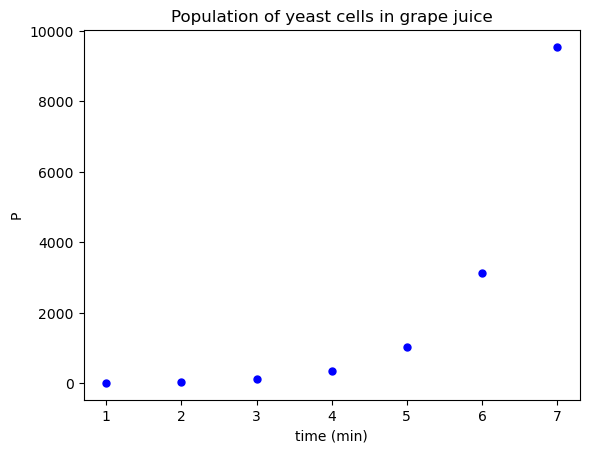

In [3]:
# Run me to plot the above data

plt.plot(tVec, PVec, "bo", markersize=5)
plt.title("Population of yeast cells in grape juice")
plt.xlabel("time (min)")
plt.ylabel("P")
plt.show()

The data are rising with a steep upward curvature, rising extremely fast at later times $t$, so we suspect that $P$ may be rising EXPONENTIALLY with $t$. To check for an exponential dependence, $P(t) \propto e^{at}$ (where $\propto$ means "proportional to"), we plot a *semi-log* graph, in which the log of the population is plotted on the y-axis. In order to obtain the natural log of the population $P$, we use the `np.log()` function.

A small aside: you might be used to denoting the natural logarithm (base-$e$ logarithm) as $\ln$ or $\text{Ln}$. And to denote the based-10 logarithm as $\log$ or $\text{Log}$. However, in physics, math and most computer languages, the standard notation is to use $\log$ to denote the natural logarithm (and with the base-10 logarithm being denoted as $\log_{10})$.

In [4]:
# Run me to take the (natural) log of PVec

logPVec = np.log(PVec)

Plotting the semi-log graph, we then obtain:

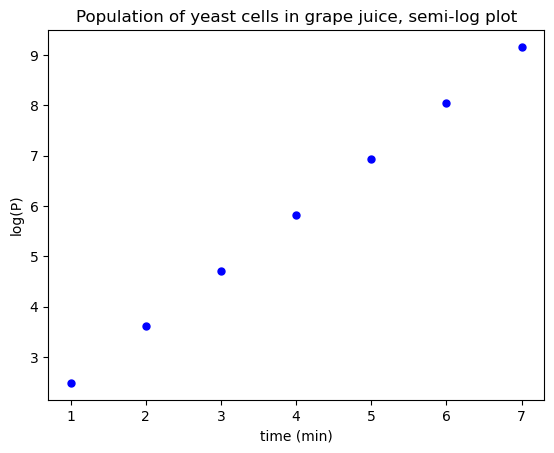

In [5]:
# Run me to make the semi-log (log[P] vs t) graph

plt.plot(tVec, logPVec, "bo", markersize=5)
plt.title("Population of yeast cells in grape juice, semi-log plot")
plt.xlabel("time (min)")
plt.ylabel("log(P)")
plt.show()

The graph reveals that a plausibly linear relationship between $\log(P)$ and $t$. It looks like the following general equation should be a good model for the data:

$$\log(P) = mt + b$$

### Your turn #1.1

Explain why we can write this equation as the model for the data.

##### Answer

We can write this equation as the model for the data because the graph shows a linear relationship between $\log(P)$ and $t$, with a nonzero intercept.

### Your turn #1.2

Estimate the slope of the line by choosing two points from the graph and calculating it. 

##### Answer

Choosing the points of (2 min, 3.6) and (6 min, 8.0) by eyeballing the graph, we approximate the slope as:

$$m = \frac{8.0 - 3.6}{6\text{ min} - 2\text{ min}} = 1.1\text{ min}^{-1}.$$

### Your turn #1.3

Explain why we assign the units of 1/minutes to the slope.

##### Answer

The units of the slope will be the units of the y-variable divided by the units of the x-variable (as slope is rise over run). Since $\log(P)$ is dimensionless and the units of time in the data are minutes, the units of the slope come out to be inverse minutes.

### Your turn #1.4

The value of the intercept $b$ is approximately 1.4. Briefly explain how you would find this value.

##### Answer

Knowing the slope is $m = 1.1\text{ min}^{-1}$, we can substitute a known point into the equation $\log(P) = mt + b$ to approximate what $b$ should be. As an example, using (6 min, 8.0) as an (approximate) point, we find:

$$8.0 = 1.1 \times 6 + b \implies b = 8 - 6.6 = 1.4$$
 

### Connecting the Linear and Exponential Equations

Now, let's connect our linear expression of $\log(P) = mt + b$, with the exponential equation $P_0\,e^{at}$.

Some logarithmic and mathematical rules that may be of use are given below:

- Rule 1 - Inverse properties: $\log_a(a^x) = x$ and $a^{\log_a(x)} = x$
- Rule 2 - Product: $\log_a(xy) = \log_a(x) + \log_a(y)$ and $e^{x+y} = e^x e^y$
- Rule 3 - Quotient: $\log_a(x/y) = \log_a(x) - \log_a(y)$ and $e^{x-y} = e^x/e^y$
- Rule 4 - Power: $\log_a(x^p) = p\log_a(x)$
- Rule 5 - Property of equalities: If you perform the same option on both sides of an equation, the sides remain equal to each other.    

### Your turn #1.5

For the following steps, indicate which rule was applied.

**Start:** $\log(P) = mt + b$

**Step 1:** $e^{\log(P)} = e^{mt + b}$.

**Step 2:** $P = e^{mt + b}$

**Step 3:** $P = e^b e^{mt}$

##### Answer

1. Property of equalities
2. Inverse property
3. Product Rule

##### 
We have two expressions for $P$: $P = P_0 e^{at}$ as well as $P=e^b e^{mt}$. We find that the slope $m$ is the coefficient of $t$ inside the exponential: $m = a$ and the prefactor $P_0$ is the exponential of the intercept: $P_0 = e^b$.

### Your turn #1.6

If we substitute in the values for $m$ and $b$, the model becomes:

$$P = 4.0e^{1.1 t}.$$

This is called exponential behavior (which is of the form $e^{t}$ and differs from a power law, which would be of the form $t^\alpha$). Explain how the coefficient 4.0 in front of the exponential was determined.

##### Answer

The coefficient is equal to $e^b$. We found that $b = 1.4$, and we therefore can calculate $e^{1.4} \sim 4.0$.

### Summary

To summarize, data that follow a straight line on a *semi-log* plot (logarithmic y-axis, linear x-axis) indicate that an exponential is the correct model, and the value of the slope gives the coefficient in the argument of the exponent. 

A customary way to write such exponentials is:

$$P(t) = P(0)e^{t/\tau},$$

such that the parameter $\tau$ has the same units as the variable $t$. In this example, the units are minutes and $\tau$ is referred to as a time constant (like we saw in the RC lab). For this particular set of data,

$$\tau = 0.9\text{ minutes}.$$


In python, we can obtain the logarithm of a vector by using the `np.log()` function on the original vector. 

In conclusion, we remark on the power of linearization; it allows us to see if a dataset has exponential behavior, and allows us to determine the coefficient in the exponent via determining the slope of the linearized dataset. Helpfully, we already know how to determine the slope of a linear looking data set. In contrast, figuring out the coefficient just by looking at the original exponential data is less obvious.

### Your turn #1.7

Explain the relationship between the time constant and the slope of the line in the semi-log plot.

##### Answer

The time constant is the inverse of the slope of the semi-log plot.

## Part 2 - Uncertainties in radiation count-rates

In this lab we will be using a Geiger counter to detect radiation from a radioactive source. Specifically, we will be using an Iron 55 source, which emits low-energy gamma rays when it decays. The Geiger counter detects ionizing radiation, such as the low-energy gamma rays from this decay. Each particle of ionizing radiation that interacts with the Geiger counter will produce a “count”. There are many factors that influence how many counts will be recorded by the Geiger counter, including how long you count for, how active the source is, how far apart the source and counter are, and how much shielding is in between source and counter.

The count-rate, $R$, is the quantity that represents the rate at which the counts are being measured,

$$R = N/t, \quad (1)$$

where $t$ is the amount of time for which you counted and $N$ the number of counts observed.

#### Uncertainty in $N$

Radioactive decay is a random process, so as with the pendulum timing measurements, there will be variability when you run multiple trials. The randomness in this case is well-described by counting statistics (specifically by the Poisson distribution). These counting statistics tell us that the uncertainty in the number of counts N is given by:

$$\delta N = \sqrt{N}.$$

This means that if you make repeated measurements of $N$ over the same time interval $t$, but keep the other variables the same, that these measurements will follow a Poisson distribution and have a standard deviation of $\sqrt{N}$. For reference, for values of $N$ of approximately 10 or more, the poisson distribution behaves like a Gaussian distribution.

#### Uncertainty in $R$

We turn our attention to calculating the uncertainty in the count-rate $R$. We can write the relative uncertainty for $R$ as:

$$\frac{\delta R}{R} = \sqrt{\left(\frac{\delta N}{N}\right)^2 + \left(\frac{\delta t}{t}\right)^2}. \quad (2)$$

### Your turn #2.1

Revisit the <a href = "https://docs.google.com/document/d/e/2PACX-1vTIsUtk7j6RnqhzD3hqYvxvvBEp20Ya3mCCQTi4ypSbqFB3CdKdIsDCitk541WsFADbQ5Feh0MsUKBz/pub" target = "_blank">Overview of Uncertainty Propagation</a> document. Which expression for uncertainty propagation was used to get from Equation (1) to Equation (2)?

##### Answer

We used the expression for propogating the uncertainty when we multiply/divide two quantities. If $z = x/y$, then:

$$\frac{\delta z}{z} = \sqrt{\left(\frac{\delta x}{x}\right)^2 + \left(\frac{\delta y}{y}\right)^2}$$

i.e. we add the relative uncertainties in quadrature.

### Your turn #2.2

Using some of our relationships above for $N$ and $\delta N$, we can rewrite Equation (2) as:

$$\frac{\delta R}{R} = \sqrt{\frac{1}{N} + \left(\frac{\delta t}{t}\right)^2}. \quad (3)$$

Show how you get from equation (2) to equation (3).

##### Answer

First we use that $\delta N/N = \sqrt{N}/N = 1/\sqrt{N}$, which gives

$$\frac{\delta R}{R} = \sqrt{\left(\frac{1}{\sqrt{N}}\right)^2 + \left(\frac{\delta t}{t}\right)^2}.$$

And finally we use $(1/\sqrt{N})^2 = 1/N$.

### Focusing on the counting statistics uncertainty, $\delta N$

In a later part of the prelab we will discuss in more detail that for typical Lab 09 measurements, $\delta N/N$ is the dominant uncertanty and $\delta t/t$ is negligible with respect to $\delta N/N$. This assumption of $\delta N/N \gg \delta t/t$ allows us to rewrite Equation (3) without the $\delta t$ term:

$$\frac{\delta R}{R} = \frac{1}{\sqrt{N}}. \quad (4)$$

With this simplified expression, let's use this to look at how counting for a longer period of time will affect the uncertainty in our count rate.

### Example 2.1

You perform a counting experiment and measure $N = 399$ counts during a $t = 49.9\text{ s}$ time interval. 

### Your turn #2.3

Calculate the relative uncertainties for this measurement: $\delta N/N$, and $\delta R/R$.

##### Answer

$\delta N/N = 1/\sqrt{N} = 1/\sqrt{400} = 1/20 = 0.05$ and $\delta R/R = \delta N/N = 0.05$.

### Your turn #2.4

Show that $R = 8.00 \pm 0.40$ counts/second for the Example 2.1 data, after we apply our regular 2 sig figs for calculated uncertainties rule.

##### Answer

$R = N/t = 399/49.9 = 7.99599$ counts/second. We also know that $\delta R/R = 0.05$, so $\delta R = 0.05 \times R = 0.40$, when rounded to 2 significant figures. Therefore by the 2 sig fig reporting rule we have $R = 8.00 \pm 0.40$ counts/second. 

### Example 2.2

You decide that you can reduce the uncertainty in your count-rate by counting for longer and decide to count for four times as long. You measure $N = 1602$ counts in a 200.2s time interval. 

### Your turn #2.5

Again, calculate the relative uncertainties for this measurement: $\delta N/N$, and $\delta R/R$.

##### Answer

$\delta N/N = 1/\sqrt{N} = 1/\sqrt{1602} \approx 0.025$ and $\delta R/R = \delta N/N = 0.025$.

### Your turn #2.6

Show that $R = 8.00 \pm 0.20$ counts/second for the Example 2.2 measurment, after we apply our regular 2 sig figs for calculated uncertainties rule.

##### Answer

$R = N/t = 1602/200.16 = 8.0036$ counts/second, and we know that $\delta R/R = 0.025$ so $\delta R = 0.025 \times R \approx 0.20$. Therefore by the 2 sig fig reporting rule we have $R = 8.00 \pm 0.20$ counts/second. 

### Your turn #2.7

Use the relative uncertainty $\delta N/N$ to explain why $\delta R$ goes down in the Example 2.2 measurement (counting for 200.2s) as compared to the Example 2.1 measurement (counting for 49.9s).

##### Answer

Counting for four times as long allowed us to increase $N$ by approximately a factor of 4. As a result $\delta N/N = 1/\sqrt{N}$ decreased by a factor of $1/\sqrt{4} = 1/2$. Since we know that $\delta R/R = \delta N/N$, collecting data for four times as long results in a count-rate uncertainty that is half of what it was in the first example.

## Part 3 - Setting up analysis code for the lab

In the lab, we will be analyzing the radiation count-rate $R$ as a function of the thickness of paper shielding $x$, measured as a count of the number of sheets of paper. We will get you to practice using the two-parameter analytic solution to minimize chi-squared ahead of time.

Below, we have a mock dataset for which we will demonstrate the process of linearization.

**These data represent how the radiation count rate, $N/t$, could change as a function of the thickness of shielding (number of sheets of paper), $x$, placed between the radiation source and the radiation detector. Notice that we don't include a $\delta x$ term since, like with our counts of pendulum cycles, we assume that our counting provides an exact number.**

In [6]:
# Run me to load the second example data set
# Make sure to hit "Generate Vectors"!

data_entry2.sheet("lab09_prelab_data2.csv")

Sheet name: lab09_prelab_data2.csv


The uncertainty $\delta N$ can be calculated by taking the square root of the $N$-vector:

In [7]:
# Run me to calculate the dN vector

del_NVec = np.sqrt(NVec)
print("NVec:", NVec)
print("del_NVec:", del_NVec)

NVec: [159.  52.  23.   8.   4.]
del_NVec: [12.60952021  7.21110255  4.79583152  2.82842712  2.        ]


Next, we want to calculate the count rate from the data. We recall that $R = N/t$, so we can calculate the count-rate vector as:

In [8]:
# Run me to calculate the R = N/t vector

RateVec = NVec / tVec

print("NVec:", NVec)
print("del_NVec:", del_NVec)
print("RateVec:", RateVec)

NVec: [159.  52.  23.   8.   4.]
del_NVec: [12.60952021  7.21110255  4.79583152  2.82842712  2.        ]
RateVec: [3.17365269 1.04627767 0.46092184 0.15936255 0.08      ]


#### Revisiting treating $\delta t/t$ as negligible compared to $\delta N/N$

Now that we are working with some example data, let's revisit our discussion of $\delta t/t$ being negligible and $\delta N/N$ being the dominant uncertainty.

First, let's calculate $\delta N/N$ and $\delta t/t$. Observe in the output that even when $\delta N/N$ is at its smallest, it is still nearly two orders of magnitude larger than $\delta t/t$. When we square each of these to sum them, $\delta N/N$ will clearly dominate.

In [9]:
# Run me to calculate the drel_N and drel_t vectors

drel_N = del_NVec / NVec
drel_t = del_tVec / tVec

print("drel_N:", drel_N)
print("drel_t:", drel_t)


drel_N: [0.07930516 0.13867505 0.20851441 0.35355339 0.5       ]
drel_t: [0.0011976  0.00120724 0.0012024  0.00119522 0.0012    ]


Let's compare $\delta R$ as calculated by Equation (3), which includes a $\delta N/N$ and as calculated by Equation (4), which neglects $\delta N/N$ with the understanding that $\delta N/N$ is the dominant uncertainty.

In [10]:
# run me to calculate dRate using Equations (3) and (4)

# From Equation (3)
del_Rate_with_dt = RateVec * np.sqrt(1 / NVec + (del_tVec / tVec)**2) 

# From Equation (4)
del_Rate_no_dt = RateVec * np.sqrt(1 / NVec)

print("del_Rate_with_dt:", del_Rate_with_dt)
print("del_Rate_no_dt:  ", del_Rate_no_dt)

del_Rate_with_dt: [0.25171573 0.1450981  0.09611045 0.05634349 0.04000012]
del_Rate_no_dt:   [0.25168703 0.14509261 0.09610885 0.05634317 0.04      ]


Looking above we can see that these values only start differing in the 4th significant figure, but we round our uncertainties to 2 significant figures so this is a much smaller difference than will ever show up in our reported $\delta R$ values. 

Below is a small chunk of code that creates a summary table of the values we were looking at above so that it is easy to compare everthing in one place.

In [11]:
# Simple script to display the arrays in a markdown‑style table.

# Column titles, split across two lines
headers_top = ["δN/N", "δt/t", "δRate",     "δRate"]
headers_bot = ["",     "",     "(with δt)", "(no δt)"]

# Gather rows
rows = list(zip(drel_N, drel_t, del_Rate_with_dt, del_Rate_no_dt))

# Determine the width of each column (max of both header lines and data length)
col_widths = [
    max(len(top), len(bot), *(len(f"{v:.5f}") for v in col))
    for top, bot, col in zip(headers_top, headers_bot, zip(*rows))
]

# Helper to format a line given a list of strings
def line(items):
    return "| " + " | ".join(f"{it:<{w}}" for it, w in zip(items, col_widths)) + " |"

# Print the two header lines
print(line(headers_top))
print(line(headers_bot))

# Print markdown separator
print("|" + "|".join("-" * (w + 2) for w in col_widths) + "|")

# Print each data row
for r in rows:
    print(line([f"{v:.5f}" for v in r]))

| δN/N    | δt/t    | δRate     | δRate   |
|         |         | (with δt) | (no δt) |
|---------|---------|-----------|---------|
| 0.07931 | 0.00120 | 0.25172   | 0.25169 |
| 0.13868 | 0.00121 | 0.14510   | 0.14509 |
| 0.20851 | 0.00120 | 0.09611   | 0.09611 |
| 0.35355 | 0.00120 | 0.05634   | 0.05634 |
| 0.50000 | 0.00120 | 0.04000   | 0.04000 |


Based on all of this, we see that the impact of including δt in our δRate calculation is negligible. Thus, we will use the version of $\delta R$ that treats $\delta t/t$ as negigble (i.e., `del_Rate_no_dt`) going forward as our `del_RateVec`

In [12]:
# Run me to calculate the dR vector, del_RateVec

del_RateVec = RateVec * np.sqrt(1 / NVec)

print("NVec:", NVec)
print("del_NVec:", del_NVec)
print("RateVec:", RateVec)
print("del_RateVec:", del_RateVec)

NVec: [159.  52.  23.   8.   4.]
del_NVec: [12.60952021  7.21110255  4.79583152  2.82842712  2.        ]
RateVec: [3.17365269 1.04627767 0.46092184 0.15936255 0.08      ]
del_RateVec: [0.25168703 0.14509261 0.09610885 0.05634317 0.04      ]


#### Working with our model

Our model for the count-rate will take the form:

$$R(x) = R_0 e^{-\mu x}$$

where $R_0 = R(0)$ is the count-rate when there is no shielding, and $\mu$ is the attenuation parameter. In order to proceed with fitting for the count-rate, we will want to linearize the data; in order to do so, we take the natural logarithm of the count-rate. Doing so, we obtain:

$$\log \left[ R(x) \right] = \log \left[ R_0 e^{-\mu x} \right],$$
$$\log \left[ R(x) \right] = \log \left[ R_0 \right] + \log \left[ e^{-\mu x} \right],$$
$$\log \left[ R(x) \right] = .$$

If we compare the right-hand side of the final line, $\log \left[R_0 \right] - \mu x$, to our typical two-parameter equation for a line, $y = mx + b$, we can write


$$mx + b = - \mu x + \log \left[ R_0 \right].$$

Here we can see that $m = -\mu$ is the slope of the linearized model and $\log(R_0) = b$ is the intercept.

To fit this model, we will want to take the natural logarithm of the count rate data. Doing so in python, we have:

In [13]:
# Run me to calculate the natural logarithm of the count rate data

logRateVec = np.log(RateVec)

print("NVec:", NVec)
print("RateVec:", RateVec)
print("logRateVec:", logRateVec)

NVec: [159.  52.  23.   8.   4.]
RateVec: [3.17365269 1.04627767 0.46092184 0.15936255 0.08      ]
logRateVec: [ 1.15488319  0.04523879 -0.77452679 -1.83657349 -2.52572864]


We will also want to obtain the uncertainty in the logarithm of the rate; we can derive this using the derivative rule for uncertainties:

$$\delta f(R) = \delta R\left|  {\frac{\mathrm{d}f}{\mathrm{d}R}} \right|$$

In our case, we have that the function $f(R)$ takes the form of $\log(R)$, so the uncertainty is:

$$\delta \log(R) = \delta R\left| \frac{\mathrm{d}\log(R)}{\mathrm{d}R}\right| = \delta R\frac{1}{R} = \frac{\delta R}{R}$$

where we have used that the derivative of the natural logarithm $\log(R)$ is $\frac{1}{R}$. We have therefore found the uncertainty in the logarithm of the rate to be $\delta R/R$. Writing this another way: if $Y = \log(R)$ then $\delta Y = \delta R/R$. Let's also calculate this in python:

In [14]:
# Run me to calculate the uncertainty in the natural logarithm of the count-rate data

del_logRateVec = del_RateVec / RateVec

print("NVec:", NVec)
print("del_NVec:", del_NVec)
print("logRateVec:", logRateVec)
print("del_logRateVec:", del_logRateVec)

NVec: [159.  52.  23.   8.   4.]
del_NVec: [12.60952021  7.21110255  4.79583152  2.82842712  2.        ]
logRateVec: [ 1.15488319  0.04523879 -0.77452679 -1.83657349 -2.52572864]
del_logRateVec: [0.07930516 0.13867505 0.20851441 0.35355339 0.5       ]


#### Plotting our count-rate data two ways

We are going to make two plots of our count-rate vs thickness data and introduce some terminology that will show up in the lab.
* `RateVec` vs `x` is typically referred to as a linear-linear graph since we have not taken the (natural) logarithm of either variable. Data in this format may be referred to as "untransformed" since we have not performed any further operations on our initial `x` or `y` variables. It is useful to graph the data in this format to ensure that the data look exponential.
* `logRateVec` vs `x` is referred to as a semilog graph, since we are taking the (natural) logarithm of the y-data, but not the x-data. Thus, semilog refers to plotted in the form: log-y vs linear-x. This will often also be referred to as "linearized" or "transformed" data since we have converted it into the form for which we expect a linear model, $y=mx+b$, to fit.


First we plot our linear-linear graph, which we expect should look like a decaying exponential.

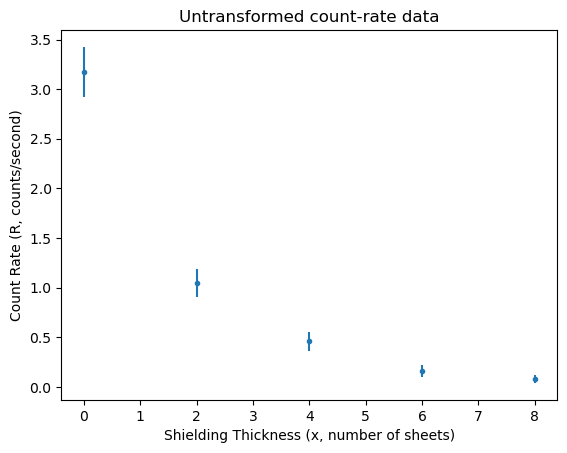

In [15]:
x_data = xVec
y_data = RateVec
del_y_data = del_RateVec

graph_title = "Untransformed count-rate data"
x_label = "Shielding Thickness (x, number of sheets)"
y_label = "Count Rate (R, counts/second)"

fig = plt.figure()
plt.errorbar(x_data, y_data, del_y_data, marker='.', linestyle='')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(graph_title)

plt.show(fig)
plt.close(fig)

Next we plot our semilog graph using the linearized data. We expect this to look linear (and it certaintly does).

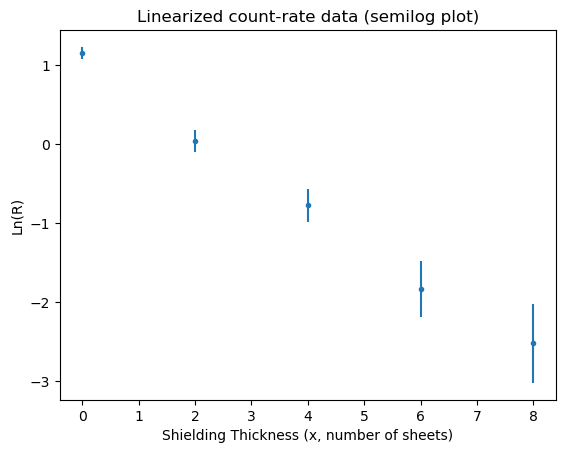

In [18]:
x_data = xVec
y_data = logRateVec
del_y_data = del_logRateVec

graph_title = "Linearized count-rate data (semilog plot)"
x_label = "Shielding Thickness (x, number of sheets)"
y_label = "Ln(R)"

fig = plt.figure()
plt.errorbar(x_data, y_data, del_y_data, marker='.', linestyle='')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(graph_title)
plt.show()

plt.show(fig)
plt.close(fig)

#### Fitting our data using the 2-parameter analytic equations

#### **Your turn #3.1**
Before running the code for the 2-parameter best-fit equations, you need to determine which representation of our data is the one we will be using as `xdata` and `ydata` in our standard fitting code.

In [20]:
# Assign the appropriate data vectors to these variables before 
# running the two-parameter fit code below

x_data = None
y_data = None
del_y_data = None

##### Answer

We want the semilog/linearized version of the data
```python
x_data = xVec
y_data = logRateVec
del_y_data = del_logRateVec
```

#### **Your turn #3.2: run the 2-paramter analytic best-fit equations**

The relevant code from the Two Parameter Analytic Fit Equations example has been copied from Prelab 08 ("2-parameter analytic best-fit solution and plotting"). **Update the Step 0 information to point it at the correct data, and to update titles and labels.**

Once you run this code, you should find you get a best-fit model with the following parameters.

```
Best fit slope, m =  -0.48915644900392674 ± 0.03512901473680299
Best fit slope, b =  1.131611406837939 ± 0.07495617683220367
chi2 = 0.3409
```

In [ ]:
### Find the best 2-parameter model corresponding to the minimized chi-squared



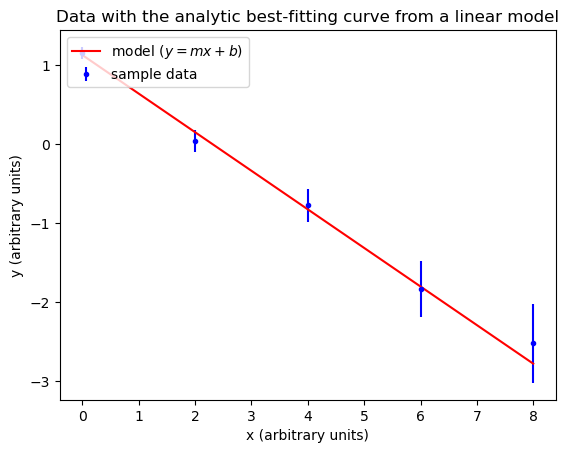

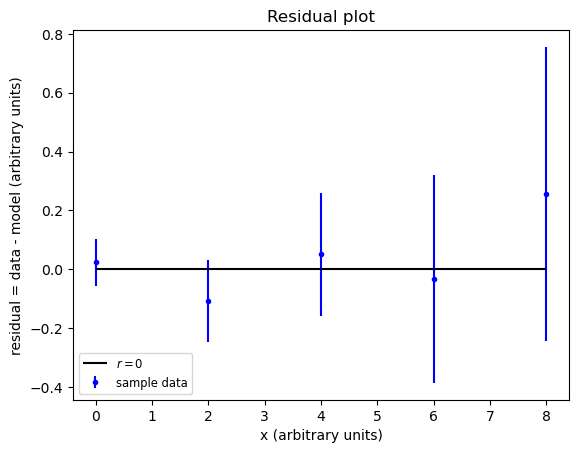

FIT REPORT
[ Model ]
    Linear model: y = mx + b
[ Fit Statistics ]
    • Fitting method : analytic chi-square minimization
    • Data points    : N = 5
    • Parameters     : P = 2
    Reduced chi-square = 0.34
[ Parameters (best-fitting values) ]
          slope: m = -0.489156  ± 0.035129  arbitrary units (7.18%)
    y-intercept: b = 1.13161    ± 0.0749562 arbitrary units (6.62%)


In [19]:
# LINEAR MODEL + ANALYTIC MINIMIZATION OF REDUCED CHI-SQUARE

########################################################################################
# Step 0: Update these variables for your own analysis
########################################################################################

# Your data vectors (the analytic minimization weights by del_y_data only)
x_data = None
y_data = None
del_y_data = None

# Units for the fitted parameters
m_units = "arbitrary units"  # adapt to your experiment
b_units = "arbitrary units"  # adapt to your experiment

# Labels for your plots
data_label = "sample data"
graph_title = "Data with the analytic best-fitting curve from a linear model"
x_label = "x (arbitrary units)"  # adapt to your experiment
y_label = "y (arbitrary units)"  # adapt to your experiment

########################################################################################
# Model – step 1: find the range of x values from the experimental data.
########################################################################################

x_min = np.min(x_data)  # find the smallest x value
x_max = np.max(x_data)  # find the largest x value

########################################################################################
# Model – step 2: generate model x values
########################################################################################

# Generate model x values between x_min and x_max for which we want to plot the model y values.
x_model = np.linspace(start=x_min, stop=x_max, num=200)  # return 200 evenly spaced values

########################################################################################
# Model – step 3: calculate the best-fitting parameters and the model y values.
########################################################################################

# Analytic best-fit parameters and their uncertainty for a linear model y = mx + b.

# Calculate the placeholder variable Z.
z = (
    np.sum(1 / del_y_data**2) * np.sum(x_data**2 / del_y_data**2)
    - np.sum(x_data / del_y_data**2)**2
    )

# Calculate the best-fit value for the slope, m, and its uncertainty, del_m.
m = 1 / z * (
    np.sum(1 / del_y_data**2) * np.sum(x_data * y_data / del_y_data**2)
    - np.sum(x_data / del_y_data**2) * np.sum(y_data / del_y_data**2)
    )
del_m = np.sqrt(1 / z * np.sum(1 / del_y_data**2))

# Calculate the best-fit value for the y-intercept, b, and its uncertainty, del_b.
b = 1 / z * (
    np.sum(x_data**2 / del_y_data**2) * np.sum(y_data / del_y_data**2)
    - np.sum(x_data / del_y_data**2) * np.sum(x_data * y_data / del_y_data**2)
    )
del_b = np.sqrt(1 / z * np.sum(x_data**2 / del_y_data**2))

# Calculate the model y values at each of the model x values.
y_model = m * x_model + b

########################################################################################
# Model – step 4: plot the model on the graph of the experimental data.
########################################################################################

# Create a new figure.
fig = plt.figure()

# Generate scatter plot
plt.errorbar(
    x=x_data, y=y_data, yerr=del_y_data,
    fmt='bo', markersize=3, label=data_label
    )  # plot experimental data
plt.title(graph_title)
plt.xlabel(x_label)
plt.ylabel(y_label)
model_label = "model ($y = mx + b$)"
plt.plot(x_model, y_model, "r-", label=model_label)  # plot model data
# Add a legend (you can change the location as needed)
plt.legend(loc='upper left')

# Show and close our scatter plot
plt.show(fig)
plt.close(fig)

########################################################################################
# Residuals – step 1: calculate the model predictions y_prediction for each of
########################################################################################

# The measured x_data values.
y_prediction = m * x_data + b

########################################################################################
# Residuals – step 2: calculate the residuals.
########################################################################################

residuals = y_data - y_prediction

########################################################################################
# Residuals – step 3: plot the residuals against the measured x_data values.
########################################################################################

# Create a new figure for the residual plot.
fig = plt.figure()

# Generate residual plot
residual_graph_title = "Residual plot"
residual_y_label = "residual = data - model (arbitrary units)"
plt.errorbar(
    x=x_data, y=residuals, yerr=del_y_data,
    fmt='bo', markersize=3, label=data_label
    )
plt.title(residual_graph_title)
plt.xlabel(x_label)  # reuse the x-label from the scatter plot
plt.ylabel(residual_y_label)

########################################################################################
# Residuals – step 4: add a horizontal line at r=0 to the plot.
########################################################################################

plt.hlines(y=0, xmin=x_min, xmax=x_max, color='k', label="$r = 0$")
# Add a legend (you can change the location as needed)
plt.legend(loc='lower left', fontsize='small')

# Show and close our residuals plot
plt.show(fig)
plt.close(fig)

########################################################################################
# FIT REPORT - Summary of the reduced chi-square analysis.
########################################################################################

# Define the number of fitting parameters ("P" in the reduced chi-square formula).
P = 2  # slope and y-intercept
N = len(x_data)

# Calculate the reduced chi-square.
reduced_chi_square = 1 / (N - P) * np.sum( (residuals / del_y_data)**2 )

# Advanced code for creating a fit report in Python with the right number of
# decimals (for the best value) and significant figures (for the uncertainty).
# Note that in the printed report, the number in parentheses next to the
# uncertainty in each parameter is the associated relative uncertainty
# (expressed as a percentage).
SIG_FIGS = 2  # constant in our class
print("FIT REPORT")
print("[ Model ]")
print(f"{'':<4}""Linear model: y = mx + b")
print("[ Fit Statistics ]")
print(f"{'':<4}{'• Fitting method':<17}: analytic chi-square minimization")
print(f"{'':<4}{'• Data points':<17}{': N = ' + str(N):<5}")
print(f"{'':<4}{'• Parameters':<17}{': P = ' + str(P):<5}")
print(f"{'':<4}"f"Reduced chi-square = {reduced_chi_square:.{SIG_FIGS}f}")
print("[ Parameters (best-fitting values) ]")
print(
    f"{'':<4}{'slope: m = ':>17}{m:<10g}{' ± ':<3}"
    f"{del_m:<10g}{m_units:<5} ({abs(del_m / m) * 100:.{SIG_FIGS}f}%)"
    )
print(
    f"{'':<4}{'y-intercept: b = ':>17}{b:<10g}{' ± ':<3}"
    f"{del_b:<10g}{b_units:<5} ({abs(del_b / b) * 100:.{SIG_FIGS}f}%)"
    )

### Your turn #3.3

From your best-fit slope `m` and y-intercept `b` values, extract the parameters $R_0$ (the zero-shielding count-rate) and $\mu$ (the attenuation coefficient). 

Recall that $b = \log(R_0)$ and $m = -\mu$.

Also note that we know from our x=0 data point that we expect $R_0$ to be approximately $159 \text{ counts}/50.1\text{ s} = 3.17\text{ counts/s}$.

##### Answer

You should have found that $\mu = 0.489 \text{ sheet}^{-1}$, remembering that our units for $x$ are sheets of paper. 

You should also have found that $R_0 = 3.1006 \text{ counts/second}$. The physical interpretation for $R_0$ is that it is what the model predicts the count-rate will be when there is no shielding.

### Your turn #3.4

From the uncertainties in $\delta m$ and $\delta b$, extract the uncertainties $\delta R_0$ and the attenuation coefficient $\delta \mu$.

Hint: By the derivative rule, we have that:

$$R_0 = e^b \implies \delta R_0 = \delta b \, e^b,$$

$$m = -\mu \implies \delta m = \delta \mu.$$

##### Answer

You should have found that $\mu = 0.489 \pm 0.035 \text{ sheet}^{-1}$ and $R_0 = 3.10 \pm 0.23 \text{ counts/second}$.

## Your turn #4.1: Preparing for Lab 09

As usual, you should take a few minutes to read through the lab instructions so that you have a sense of how you will be spending your time during the lab. Copy any prelab code that you need into your lab notebook. Note that we have provided minimal structure in this lab notebook.

# Submit

Steps for submission:

1. Click: Run => Run_All_Cells
2. Read through the notebook to ensure all the cells executed correctly and without error.
3. File => Save_and_Export_Notebook_As->HTML
4. Inspect your html file
5. Upload the HTML document to the lab submission assignment on Canvas.